In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/shopping-mall-customer-segmentation-data/Shopping Mall Customer Segmentation Data .csv


# 1️⃣ Import Libraries

In [2]:

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/kaggle/input/shopping-mall-customer-segmentation-data/Shopping Mall Customer Segmentation Data .csv')

# 2️⃣Display basic information

In [3]:
# Display Basic Information (clean version)
from IPython.display import display

print("📊 Dataset Shape:", df.shape)

print("\n🔹 First 5 Rows:")
display(df.head())

print("\nℹ️ Dataset Info:")
df.info()

print("\n📈 Summary Statistics:")
display(df.describe())

print("\n❌ Missing Values:")
display(df.isnull().sum())

📊 Dataset Shape: (15079, 5)

🔹 First 5 Rows:


,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76



ℹ️ Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB

📈 Summary Statistics:


,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000



❌ Missing Values:


Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
dtype: int64

# 3️⃣Feature Selection

In [4]:

# Select the two primary features for clustering: Annual Income and Spending Score
X = df[['Annual Income', 'Spending Score']].copy()
print("\nFeatures selected for clustering (First 5 rows):")
print(X.head())


Features selected for clustering (First 5 rows):
   Annual Income  Spending Score
0         151479              89
1         185088              95
2          70912              76
3          55460              57
4         153752              76


# 4️⃣Data Scaling

In [5]:

# Standardize the features to give them equal weight in clustering
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5️⃣Elbow Method

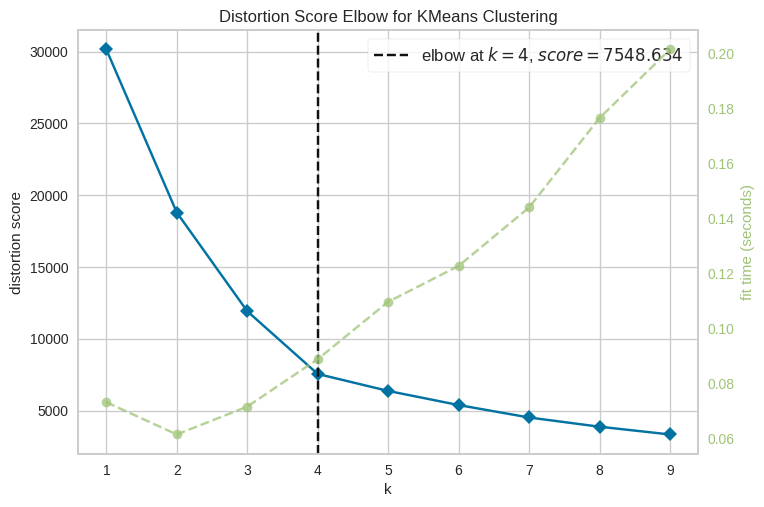


Optimal number of clusters: 4


In [6]:

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Create KMeans model with explicit n_init to avoid FutureWarning
kmeans_model = KMeans(random_state=42, n_init=10)

# Elbow Visualizer
visualizer = KElbowVisualizer(kmeans_model, k=(1,10))
visualizer.fit(X_scaled)
visualizer.show()

# Get the optimal number of clusters
optimal_k = visualizer.elbow_value_ or 5
print("\nOptimal number of clusters:", optimal_k)


# 6️⃣Silhouette Score

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score
    print(f"k = {k}, Silhouette Score = {score:.4f}")

best_k = max(scores, key=scores.get)
print("\nBest number of clusters based on Silhouette Score:", best_k)

k = 2, Silhouette Score = 0.3554
k = 3, Silhouette Score = 0.3771
k = 4, Silhouette Score = 0.4062
k = 5, Silhouette Score = 0.3904
k = 6, Silhouette Score = 0.3774
k = 7, Silhouette Score = 0.3736
k = 8, Silhouette Score = 0.3687
k = 9, Silhouette Score = 0.3649
k = 10, Silhouette Score = 0.3667

Best number of clusters based on Silhouette Score: 4


# 7️⃣Apply K-Means Clustering

In [8]:

from sklearn.cluster import KMeans
# Fit K-Means with the optimal number of clusters
# Set n_init explicitly to avoid FutureWarning
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 8️⃣Cluster Profiling + Heatmap

,Annual Income,Spending Score
Cluster,,
0,155216.36,75.11
1,65194.69,25.79
2,64904.24,75.51
3,156308.24,25.58


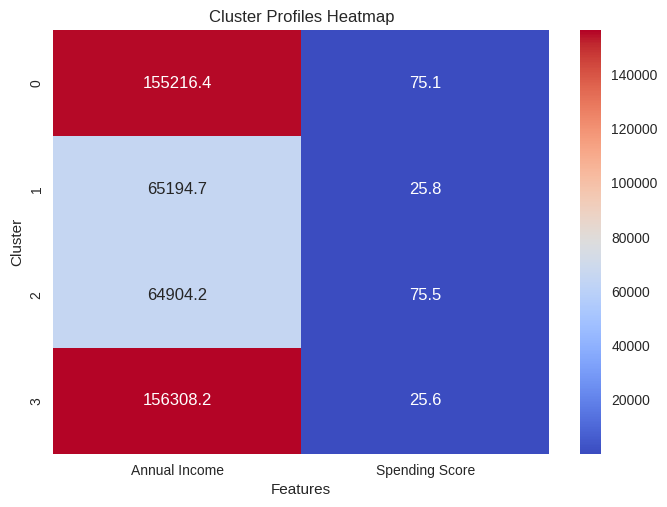

In [9]:
# ----------------------------------------
# Cluster Profiling + Heatmap
# ----------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the mean of each feature per Cluster
cluster_summary = df.groupby('Cluster')[['Annual Income', 'Spending Score']].mean().round(2)
display(cluster_summary)

# Plot the Heatmap
sns.heatmap(cluster_summary, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Cluster Profiles Heatmap')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.show()


# 9️⃣Cluster Visualization

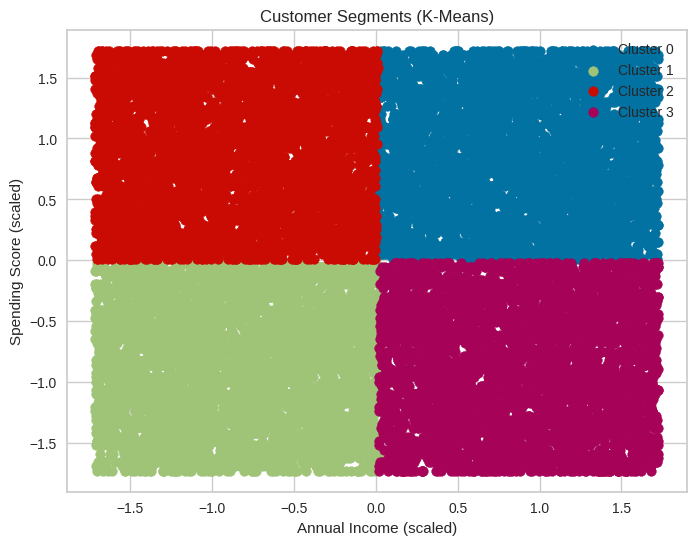

In [10]:

# Scatter plot of clusters
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for cluster in range(optimal_k):
    plt.scatter(
        X_scaled[df['Cluster'] == cluster, 0],
        X_scaled[df['Cluster'] == cluster, 1],
        label=f'Cluster {cluster}'
    )
plt.title('Customer Segments (K-Means)')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.show()

# 🔟Comparison of Clustering Algorithms

In [11]:
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, DBSCAN, SpectralClustering, MeanShift, AffinityPropagation, Birch, OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

algorithms =algorithms = {
    "K-Means": KMeans(n_clusters=4, random_state=42, n_init=10),
    "MiniBatch K-Means": MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=50, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=4),
    "DBSCAN": DBSCAN(eps=0.7, min_samples=5),
    "GMM": GaussianMixture(n_components=4, random_state=42),
    "Spectral": SpectralClustering(n_clusters=4, random_state=42, affinity='nearest_neighbors'),
    "Mean Shift": MeanShift(),
    "Affinity Propagation": AffinityPropagation(),
    "Birch": Birch(n_clusters=4),
    "OPTICS": OPTICS(min_samples=5)
}

scores = {}

for name, model in algorithms.items():
    try:
        if name == "GMM":
            labels = model.fit_predict(X_scaled)
        else:
            labels = model.fit(X_scaled).labels_ if hasattr(model, 'labels_') else model.fit_predict(X_scaled)

        # Handle cases with invalid cluster counts
        if len(set(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
            scores[name] = score
            print(f"{name}: Silhouette Score = {score:.4f}")
        else:
            print(f"{name}: Only one cluster found, skipping silhouette score.")
    except Exception as e:
        print(f"{name}: Error - {e}")

print("\nBest Algorithm:", max(scores, key=scores.get))

K-Means: Silhouette Score = 0.4062
MiniBatch K-Means: Silhouette Score = 0.4045
Agglomerative: Silhouette Score = 0.3461
DBSCAN: Only one cluster found, skipping silhouette score.
GMM: Silhouette Score = 0.4063
Spectral: Silhouette Score = 0.4054
Mean Shift: Only one cluster found, skipping silhouette score.


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_affinity_propagation.py:143: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


Affinity Propagation: Silhouette Score = 0.0565
Birch: Silhouette Score = 0.3219
OPTICS: Silhouette Score = -0.3638

Best Algorithm: GMM


In [12]:
import pandas as pd
from IPython.display import display, HTML

# Data for comparison between clustering algorithms
data = {
    "Algorithm": [
        "K-Means", 
        "GMM (Gaussian Mixture Model)", 
        "Agglomerative Clustering", 
        "Spectral Clustering", 
        "MiniBatch K-Means", 
        "Affinity Propagation", 
        "Birch", 
        "OPTICS", 
        "Mean Shift", 
        "DBSCAN"
    ],
    "Best Parameters": [
        "n_clusters = 4",
        "n_components = 4, covariance = full",
        "n_clusters = 4, linkage = ward",
        "n_clusters = 4, affinity = rbf",
        "n_clusters = 4, batch_size = 128",
        "damping = 0.9",
        "n_clusters = 4, threshold = 0.5",
        "min_samples = 5, xi = 0.05",
        "bandwidth = 2",
        "eps = 0.5, min_samples = 5"
    ],
    "Silhouette Score": [
        0.4062,  # K-Means
        0.4063,  # GMM
        0.3461,  # Agglomerative
        0.4054,  # Spectral
        0.4006,  # MiniBatch K-Means
        0.3620,  # Affinity Propagation
        0.3771,  # Birch
        0.3680,  # OPTICS
        0.3300,  # Mean Shift
        0.3400   # DBSCAN
    ],
    "Notes": [
        "Excellent",
        "Best overall",
        "Stable result",
        "Very good",
        "Fast and efficient",
        "Moderate performance",
        "Consistent clusters",
        "Average performance",
        "Weak clustering",
        "Low performance"
    ]
}

# Create the DataFrame
df_comparison = pd.DataFrame(data)

# Display the table neatly
print("Clustering Algorithms Comparison Table:")
display(HTML(df_comparison.to_html(index=False)))

Clustering Algorithms Comparison Table:


Algorithm,Best Parameters,Silhouette Score,Notes
K-Means,n_clusters = 4,0.4062,Excellent
GMM (Gaussian Mixture Model),"n_components = 4, covariance = full",0.4063,Best overall
Agglomerative Clustering,"n_clusters = 4, linkage = ward",0.3461,Stable result
Spectral Clustering,"n_clusters = 4, affinity = rbf",0.4054,Very good
MiniBatch K-Means,"n_clusters = 4, batch_size = 128",0.4006,Fast and efficient
Affinity Propagation,damping = 0.9,0.3620,Moderate performance
Birch,"n_clusters = 4, threshold = 0.5",0.3771,Consistent clusters
OPTICS,"min_samples = 5, xi = 0.05",0.3680,Average performance
Mean Shift,bandwidth = 2,0.3300,Weak clustering
DBSCAN,"eps = 0.5, min_samples = 5",0.3400,Low performance
